In [3]:
import os
import sys
sys.path.append(os.path.abspath('../scripts'))
fig_path      = '../figures/'
data_path     = '../data/'

In [4]:
import netCDF4 as nc
import numpy as np
import xarray as xr
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
import seaborn as sns
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as ticker
from proj_utils import *
from mapping_utils import *
from plotting_utils import *

In [5]:
nao_c = '#dc267f'
eap_c = '#fe6100'

## (1) Load and filter time series 

In [6]:
gsi = xr.open_dataarray(data_path + 'gsi_altimetry_timeseries.nc')
nao = xr.open_dataarray(data_path + 'nao_era5_timeseries.nc')
eap = xr.open_dataarray(data_path + 'eap_era5_timeseries.nc')

In [7]:
# --- Filter the time series with Lanczos bandpass filter ---
gsi_f    = lanczos_bandpass(gsi, low_freq = 12*6, high_freq = 12*11, window = 12) 
gsi_f    = (gsi_f - gsi_f.mean(dim='time'))/gsi_f.std(dim = 'time')

nao_f    = lanczos_bandpass(nao, low_freq = 12*6, high_freq = 12*11, window = 12) 
nao_f    = (nao_f - nao_f.mean(dim='time'))/nao_f.std(dim = 'time')

eap_f    = lanczos_bandpass(eap, low_freq = 12*6, high_freq = 12*11, window = 12) 
eap_f    = (eap_f - eap_f.mean(dim='time'))/eap_f.std(dim = 'time')

In [8]:
# --- Drop nans from filtering ---
gsi_f = gsi_f.dropna(dim='time')
nao_f = nao_f.dropna(dim='time')
eap_f = eap_f.dropna(dim='time')

## (2) Calculate lead/lag relationships and confidence intervals

In [9]:
# --- For the full time series, calculate 10 years of lags in either direction ---
n_lags = 12*10

In [10]:
# --- NAO/GSI Lags --- 
nao_gsi_corrs    = lagged_corr(nao_f, gsi_f, n_lags) # Calculate Lagged Correlations, NAO leads at - lags
nao_gsi_corrs    = np.array(nao_gsi_corrs)           # Convert to array
lci_ng,uci_ng    = get_cis(nao_f, gsi_f, n_lags)     # Calculate confidence intervals

In [11]:
# --- EAP/GSI Lags ---
eap_gsi_corrs    = lagged_corr(eap_f, gsi_f, n_lags) # Calculate Lagged Correlations, EAP leads at - lags
eap_gsi_corrs    = np.array(eap_gsi_corrs)           # Convert to array
lci_eg,uci_eg    = get_cis(eap_f, gsi_f, n_lags)     # Calculate confidence intervals

## (3) Plot lead/lag for full time series

In [12]:
# --- For plotting: Grab indices of points that exceed confidence threshold ---
ix_ng = []
for l in range(len(nao_gsi_corrs)):
        if nao_gsi_corrs[l] > uci_ng[l] or nao_gsi_corrs[l] < lci_ng[l]:
            ix_ng.append(l)

ix_eg = []
for l in range(len(eap_gsi_corrs)):
        if eap_gsi_corrs[l] > uci_eg[l] or eap_gsi_corrs[l] < lci_eg[l]:
            ix_eg.append(l)

In [13]:
# --- Make array of lags for plotting ---
lags_array      = np.arange(-n_lags,n_lags+1)       

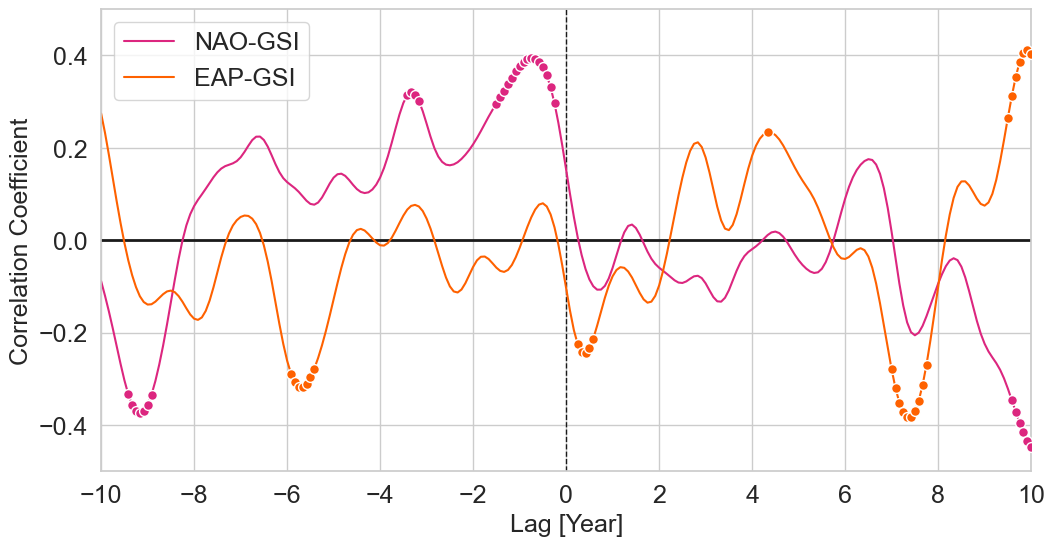

In [14]:
style   = sns.set_style("whitegrid")

fig     = plt.figure(figsize=(12, 6))

zline   = plt.axhline(0, color='k', linewidth=2)
yline   = plt.axvline(0, color='k', linewidth=1, linestyle = '--')

# --- NAO/GSI lead/lag --- 
lags_nao  = plt.plot(lags_array/12,nao_gsi_corrs, c = nao_c, label = 'NAO-GSI')
sigs_nao  = plt.scatter(lags_array[ix_ng]/12, nao_gsi_corrs[ix_ng], s=50, color = nao_c, edgecolors='w',zorder = 10)

# --- EAP/GSI lead/lag --- 
lags_eap  = plt.plot(lags_array/12,eap_gsi_corrs, c = eap_c, label = 'EAP-GSI')
sigs_eao  = plt.scatter(lags_array[ix_eg]/12, eap_gsi_corrs[ix_eg], s=50, color = eap_c, edgecolors='w',zorder = 10)

xtix = plt.yticks(fontsize=18)
ytix = plt.xticks(np.arange(-10,11,2),fontsize=18)
ylab = plt.ylabel('Correlation Coefficient', fontsize = 18)
xlab = plt.xlabel('Lag [Year]',fontsize = 18)
plt.xlim(lags_array[0]/12,lags_array[-1]/12)
plt.ylim(-0.5,0.5)
plt.legend(fontsize = 18)
plt.savefig(fig_path + 'lead_lag_nao_eap_gs_full_ts.png', format='png', bbox_inches="tight",dpi=500)

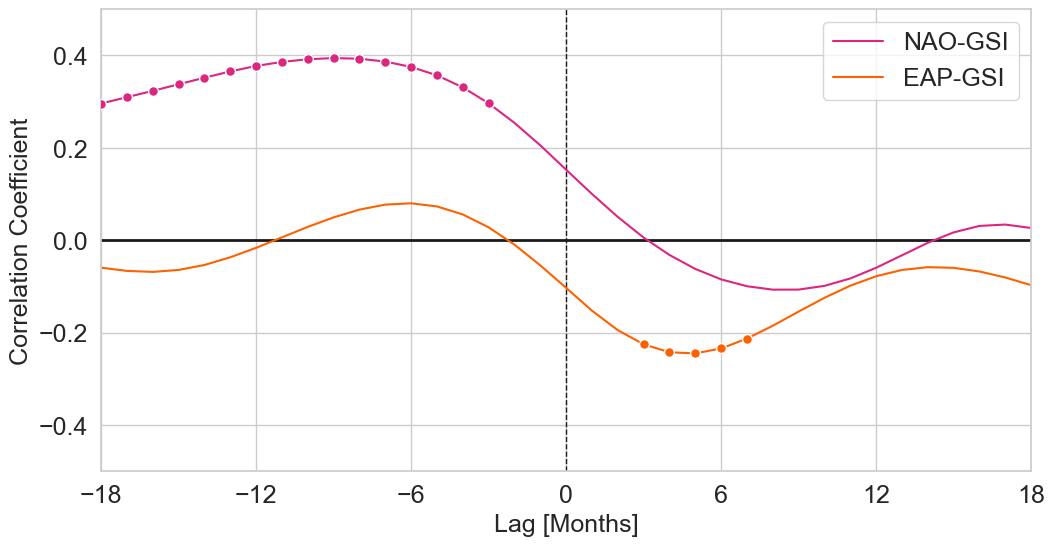

In [15]:
style   = sns.set_style("whitegrid")

fig     = plt.figure(figsize=(12, 6))

zline   = plt.axhline(0, color='k', linewidth=2)
yline   = plt.axvline(0, color='k', linewidth=1, linestyle = '--')

# --- NAO/GSI lead/lag --- 
lags_nao  = plt.plot(lags_array,nao_gsi_corrs, c = nao_c, label = 'NAO-GSI')
sigs_nao  = plt.scatter(lags_array[ix_ng], nao_gsi_corrs[ix_ng], s=50, color = nao_c, edgecolors='w',zorder = 10)

# --- EAP/GSI lead/lag --- 
lags_eap  = plt.plot(lags_array,eap_gsi_corrs, c = eap_c, label = 'EAP-GSI')
sigs_eao  = plt.scatter(lags_array[ix_eg], eap_gsi_corrs[ix_eg], s=50, color = eap_c, edgecolors='w',zorder = 10)

xtix = plt.yticks(fontsize=18)
ytix = plt.xticks(np.arange(-18,19,6),fontsize=18)
ylab = plt.ylabel('Correlation Coefficient', fontsize = 18)
xlab = plt.xlabel('Lag [Months]',fontsize = 18)
plt.xlim(-18,18)
plt.ylim(-0.5,0.5)
plt.legend(fontsize = 18)
plt.savefig(fig_path + 'lead_lag_nao_eap_gs_full_ts_cropped.png', format='png', bbox_inches="tight",dpi=500)

## (4) Calculate lead-lag for each window & plot

In [24]:
window_sz     = 48   # 4 yrs
n_lags        = 18*1
lags_array_wn = np.arange(-n_lags,n_lags+1) 

nao_gsi = np.zeros(((n_lags*2)+1,len(gsi_f)-(window_sz)))
eap_gsi = np.zeros(((n_lags*2)+1,len(gsi_f)-(window_sz)))

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    for c in range(len(gsi_f)-(window_sz)):
        # --- Slice time series ---
        gsi_temp   = gsi_f.sel(time = slice(gsi_f.time[c].data,gsi_f.time[c+window_sz].data))
        nao_temp   = nao_f.sel(time = slice(nao_f.time[c].data,nao_f.time[c+window_sz].data))
        eap_temp   = eap_f.sel(time = slice(eap_f.time[c].data,eap_f.time[c+window_sz].data))

        # --- NAO/GSI lead/lags ---
        nao_gsi_temp = lagged_corr(nao_temp, gsi_temp, n_lags)                 # Calculate Lagged Correlations
        nao_gsi_temp = np.array(nao_gsi_temp)                                  # Convert to array
        nao_gsi[:,c] = nao_gsi_temp
        #lci_nao_gsi_temp,uci_nao_gsi_temp = get_cis(nao_temp, gsi_temp,n_lags) # Calculate confidence intervals

        # --- EAP/GSI lead/lags ---
        eap_gsi_temp = lagged_corr(eap_temp, gsi_temp, n_lags)      # Calculate Lagged Correlations
        eap_gsi_temp = np.array(eap_gsi_temp)                       # Convert to array
        eap_gsi[:,c] = eap_gsi_temp
        #lci_eap_gsi_temp,uci_eap_gsi_temp = get_cis(eap_temp, gsi_temp,n_lags)      # Calculate confidence intervals

In [25]:
eap_gsi = eap_gsi.T

In [26]:
nao_gsi = nao_gsi.T

## (5) Create clusters by shape (k-means)

In [40]:
all_curves = np.stack((nao_gsi,eap_gsi))

In [41]:
x_curves = np.swapaxes(all_curves, 0, 1)
x_curves   = all_curves.reshape(302, -1)

In [42]:
from sklearn.cluster import KMeans
kmeans  = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(x_curves)

In [43]:
num_clusters = 4
lags = np.arange(-18,19)

## (6) Plot cluster shapes with error 

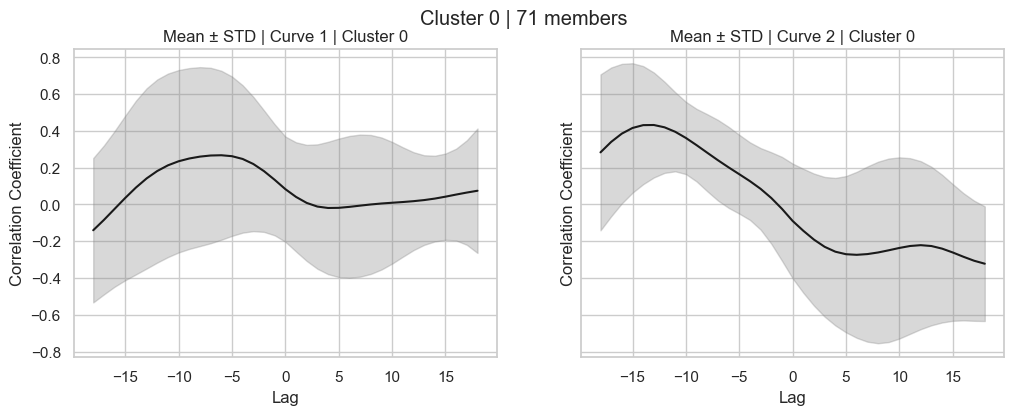

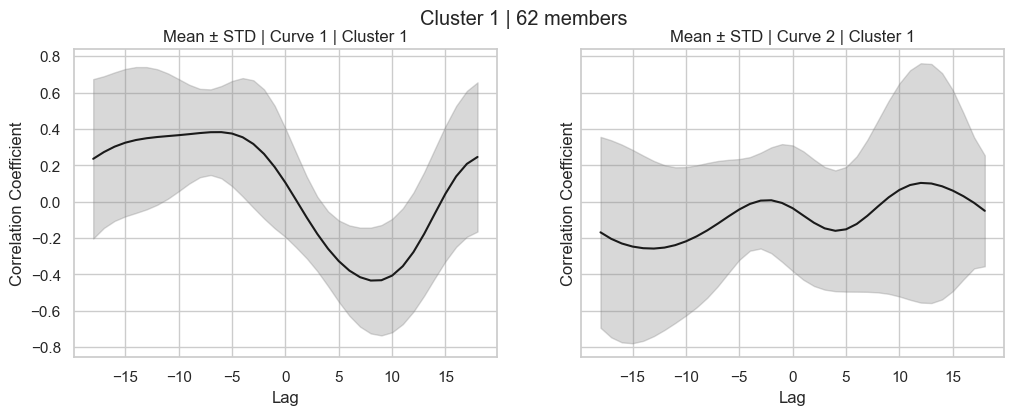

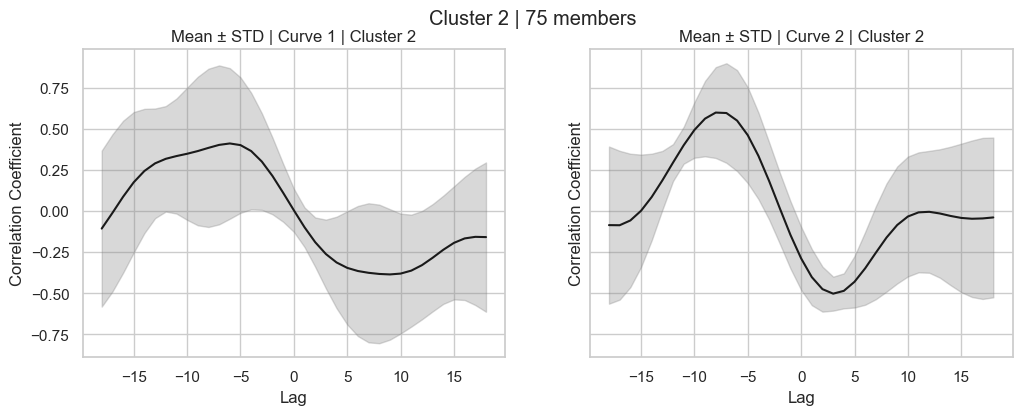

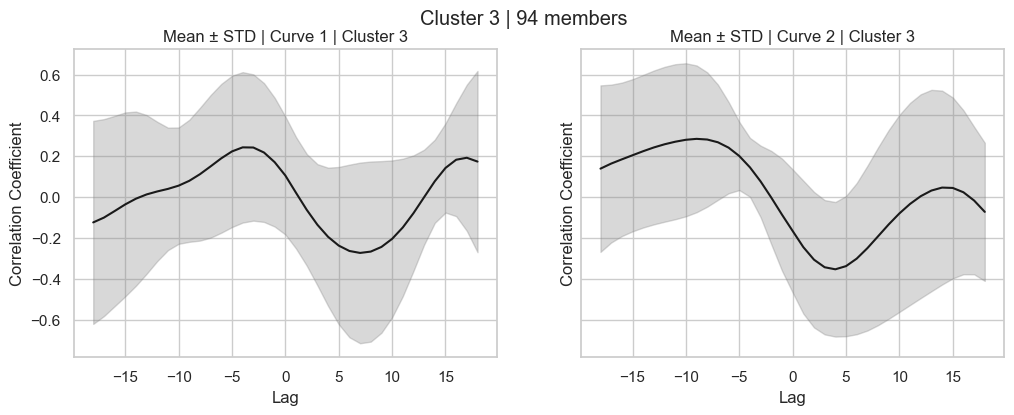

In [44]:
for k in range(num_clusters):
    idx = np.where(labels == k)[0]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for j in range(2):
        # Get all curves for this cluster & curve type
        curves = all_curves[j, idx, :]

        mean_curve = curves.mean(axis=0)
        std_curve = curves.std(axis=0)

        ax[j].plot(lags, mean_curve, color='k')
        ax[j].fill_between(lags, mean_curve - std_curve, mean_curve + std_curve,
                           color='gray', alpha=0.3)
        ax[j].set_title(f'Mean ± STD | Curve {j+1} | Cluster {k}')
        ax[j].set_xlabel('Lag')
        ax[j].set_ylabel('Correlation Coefficient')

    plt.suptitle(f'Cluster {k} | {len(idx)} members')
    plt.show()

## (5) Plotting all vars by cluster

In [47]:
df = pd.read_csv(data_path + 'composite_logs.csv')

In [48]:
unnamed_cols = [col for col in df.columns if 'Unnamed: 0' in col]
df = df.drop(columns=unnamed_cols)

In [49]:
df['cluster'] = labels

In [51]:
# --- Colour coordinate clusters ---
c_1 = '#648fff'
c_2 = '#dc267f'
c_3 = '#fe6100'
c_4 = '#ffb000'

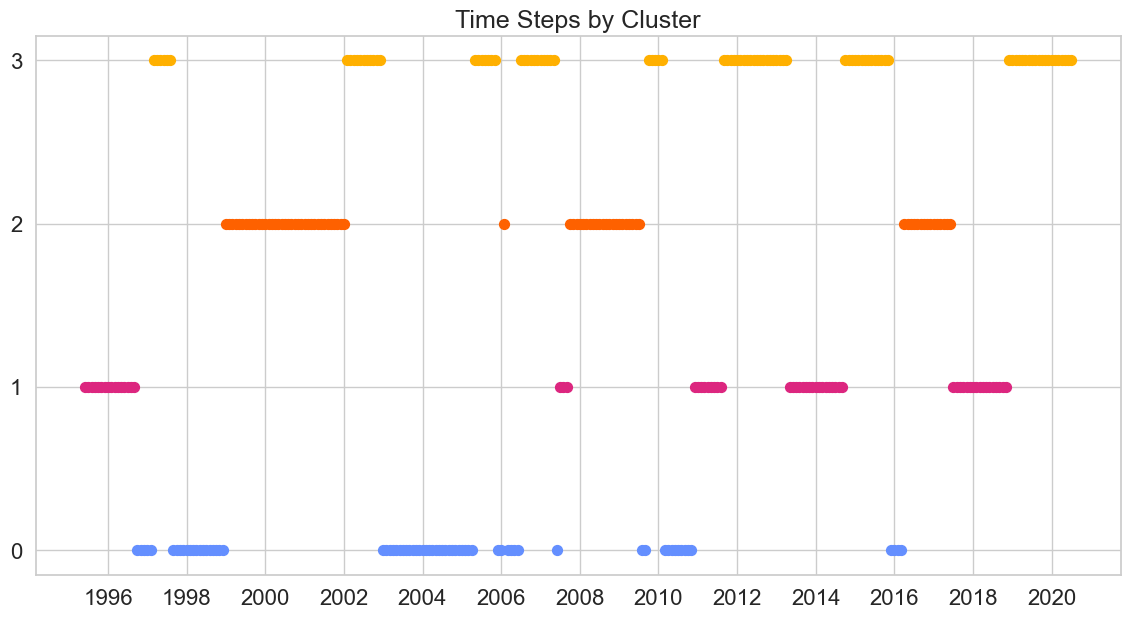

In [52]:
# --- Plot time series of clusters ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['cluster'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['cluster'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['cluster'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['cluster'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['cluster'][df['cluster'] == 3],c=c_4, s=50)

plt.title('Time Steps by Cluster',fontsize = 18)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(0,4),fontsize = 16)

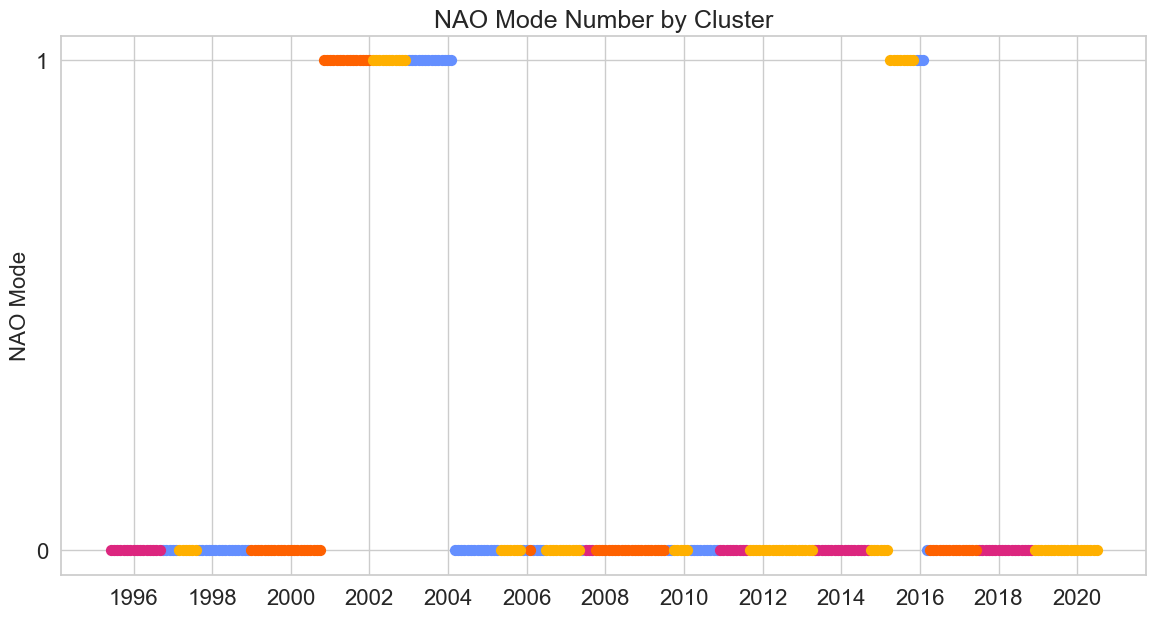

In [53]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['nao_mode_num'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['nao_mode_num'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['nao_mode_num'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['nao_mode_num'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['nao_mode_num'][df['cluster'] == 3],c=c_4, s=50)
plt.title('NAO Mode Number by Cluster',fontsize = 18)
plt.ylabel('NAO Mode', fontsize = 16)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(0,2),fontsize = 16)

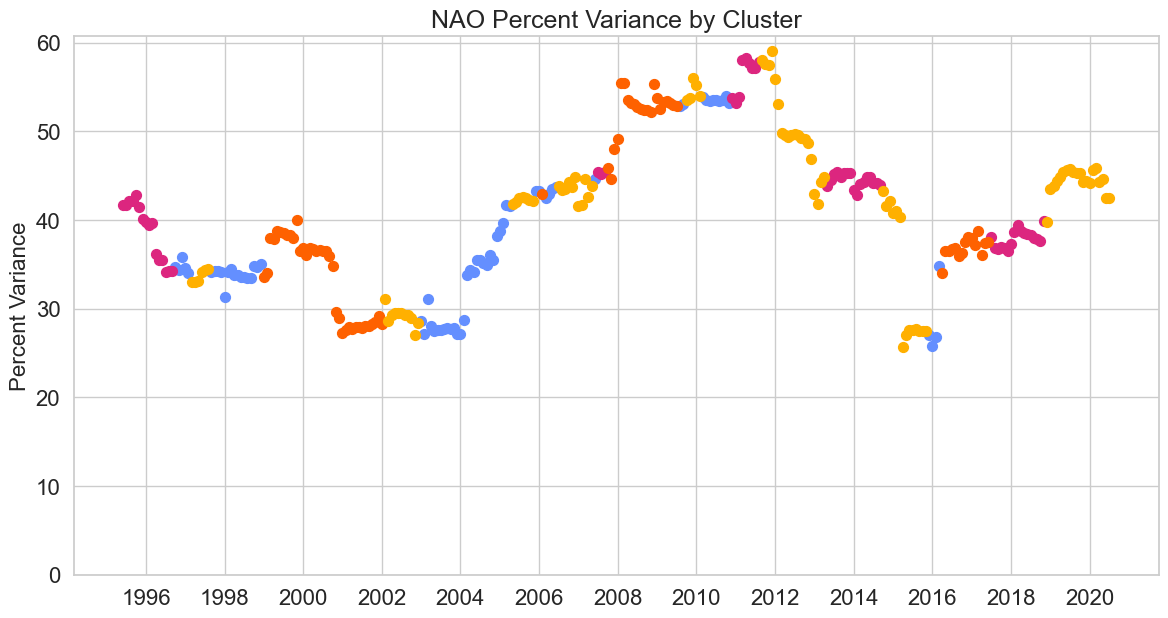

In [54]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['per_var_nao'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['per_var_nao'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['per_var_nao'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['per_var_nao'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['per_var_nao'][df['cluster'] == 3],c=c_4, s=50)
plt.title('NAO Percent Variance by Cluster',fontsize = 18)
plt.ylabel('Percent Variance', fontsize = 16)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(0,61,10),fontsize = 16)

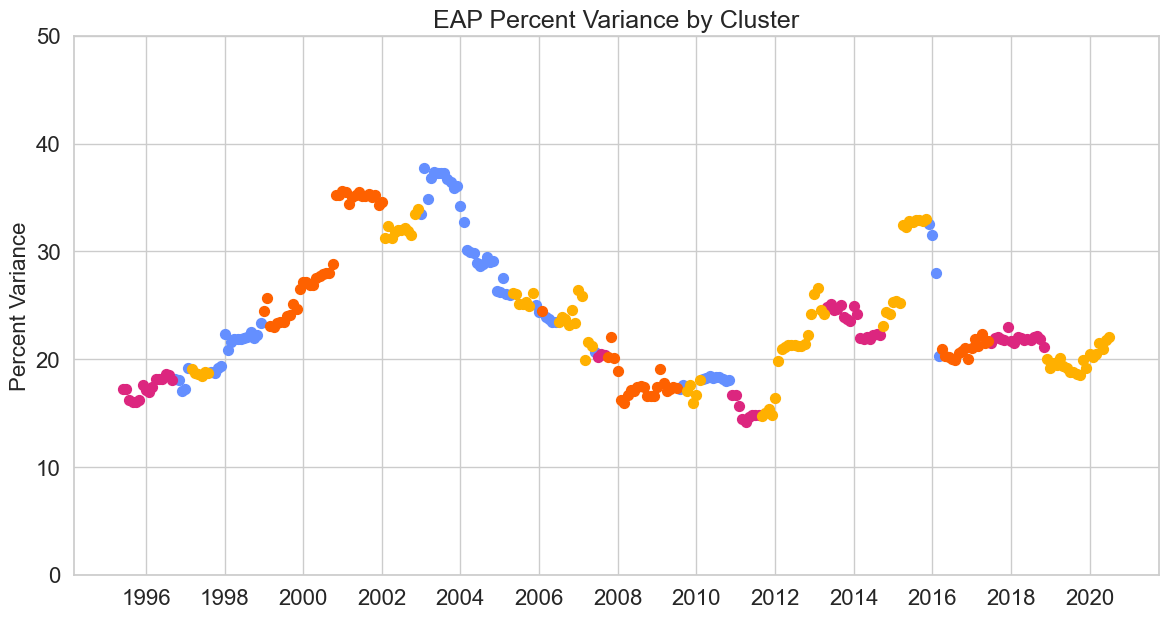

In [55]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['per_var_eap'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['per_var_eap'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['per_var_eap'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['per_var_eap'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['per_var_eap'][df['cluster'] == 3],c=c_4, s=50)
plt.title('EAP Percent Variance by Cluster',fontsize = 18)
plt.ylabel('Percent Variance', fontsize = 16)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(0,51,10),fontsize = 16)

In [56]:
df['total_per_var'] = df['per_var_eap'] + df['per_var_nao']

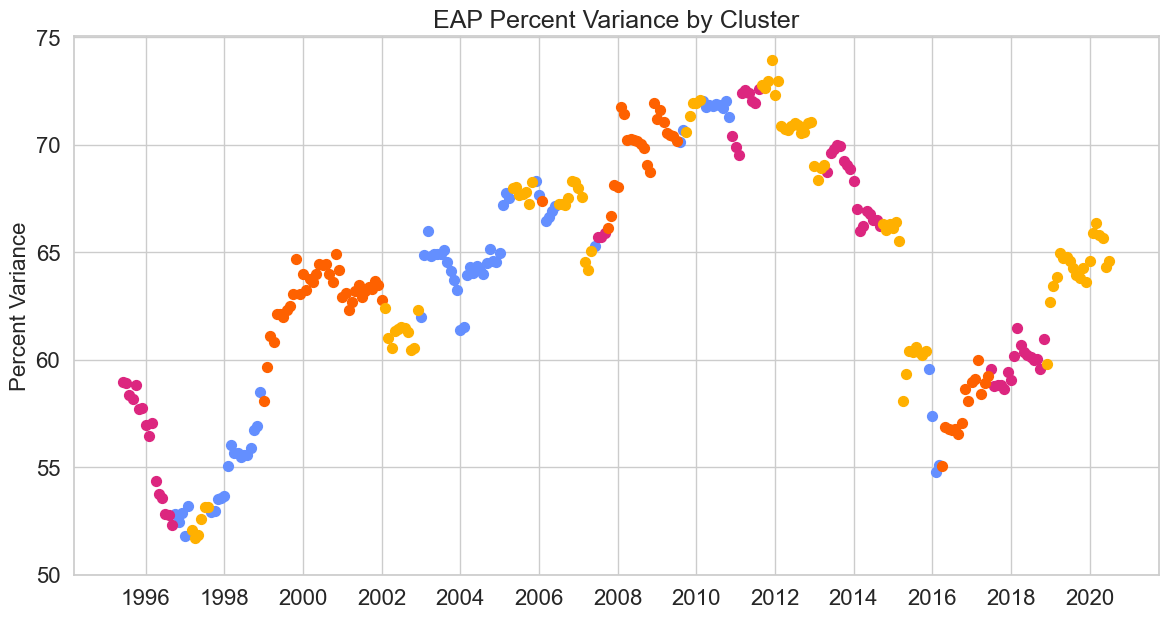

In [57]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['total_per_var'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['total_per_var'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['total_per_var'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['total_per_var'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['total_per_var'][df['cluster'] == 3],c=c_4, s=50)
plt.title('EAP Percent Variance by Cluster',fontsize = 18)
plt.ylabel('Percent Variance', fontsize = 16)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(50,80,5),fontsize = 16)

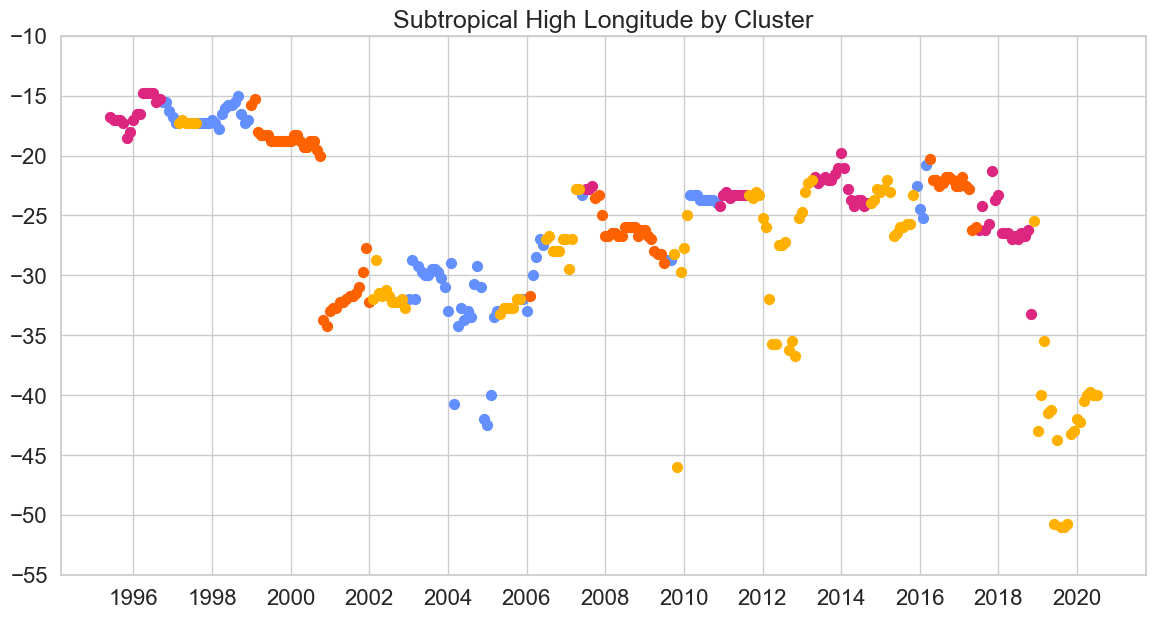

In [58]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['subtrop_high_long'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['subtrop_high_long'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['subtrop_high_long'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['subtrop_high_long'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['subtrop_high_long'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Subtropical High Longitude by Cluster',fontsize = 18)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-55,-9,5),fontsize = 16)

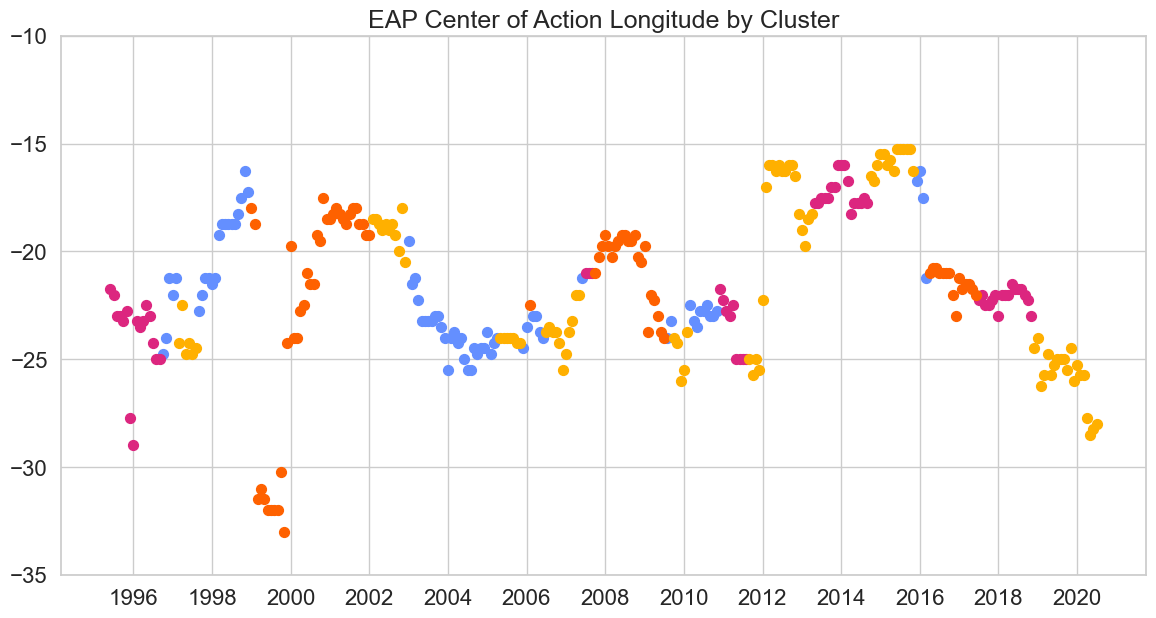

In [59]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['eap_long'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['eap_long'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['eap_long'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['eap_long'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['eap_long'][df['cluster'] == 3],c=c_4, s=50)
plt.title('EAP Center of Action Longitude by Cluster',fontsize = 18)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-35,-9,5),fontsize = 16)

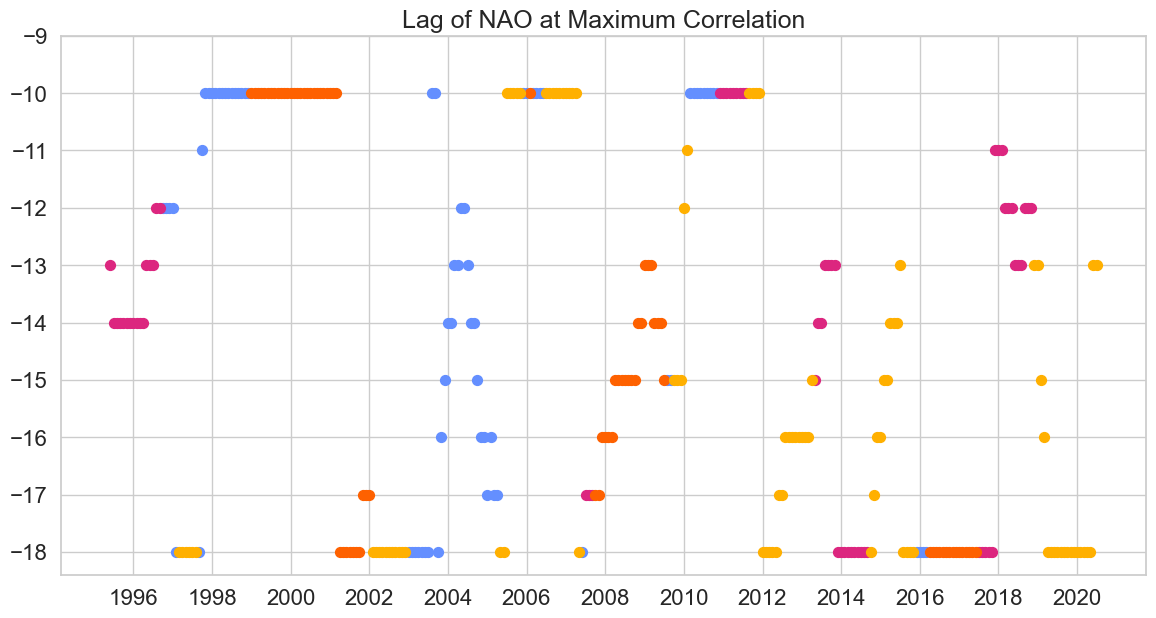

In [60]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['max_lag_nao'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['max_lag_nao'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['max_lag_nao'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['max_lag_nao'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['max_lag_nao'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Lag of NAO at Maximum Correlation',fontsize = 18)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-18,-8),fontsize = 16)

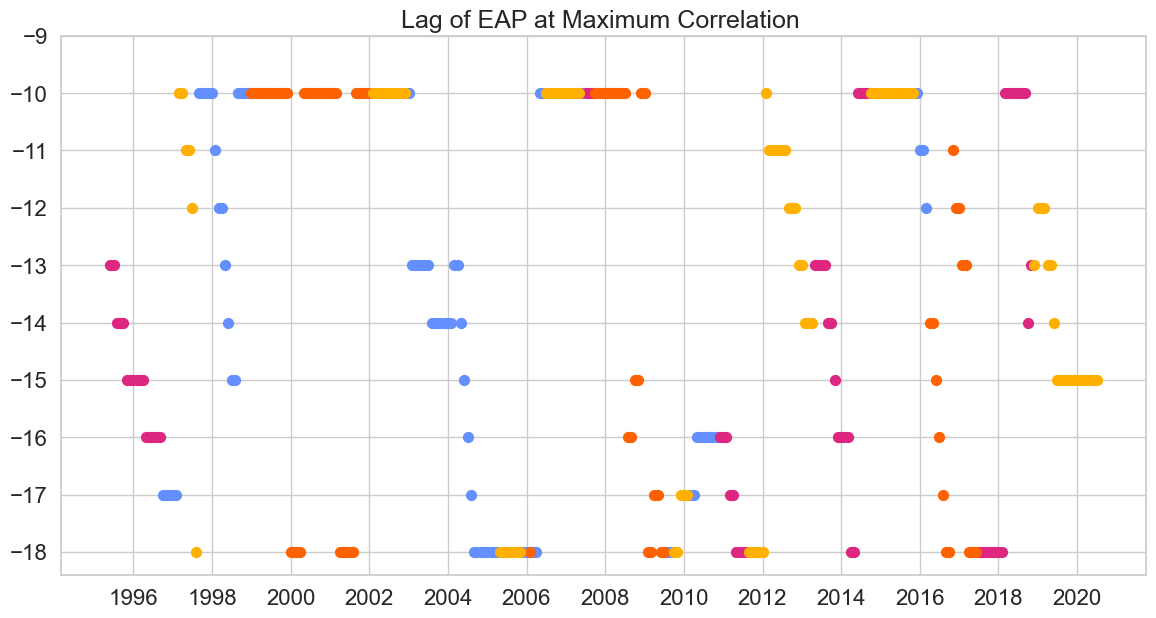

In [61]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['max_lag_eap'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['max_lag_eap'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['max_lag_eap'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['max_lag_eap'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['max_lag_eap'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Lag of EAP at Maximum Correlation ',fontsize = 18)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-18,-8),fontsize = 16)

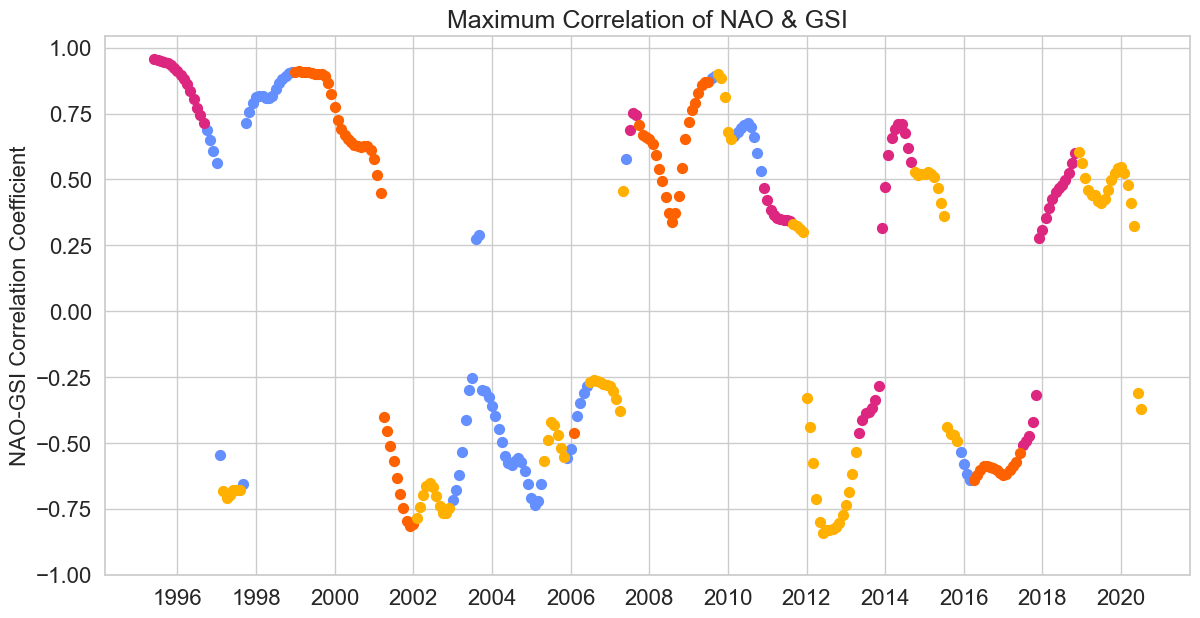

In [62]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['max_corr_nao'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['max_corr_nao'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['max_corr_nao'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['max_corr_nao'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['max_corr_nao'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Maximum Correlation of NAO & GSI',fontsize = 18)
plt.ylabel('NAO-GSI Correlation Coefficient', fontsize = 16)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-1,1.1,0.25),fontsize = 16)

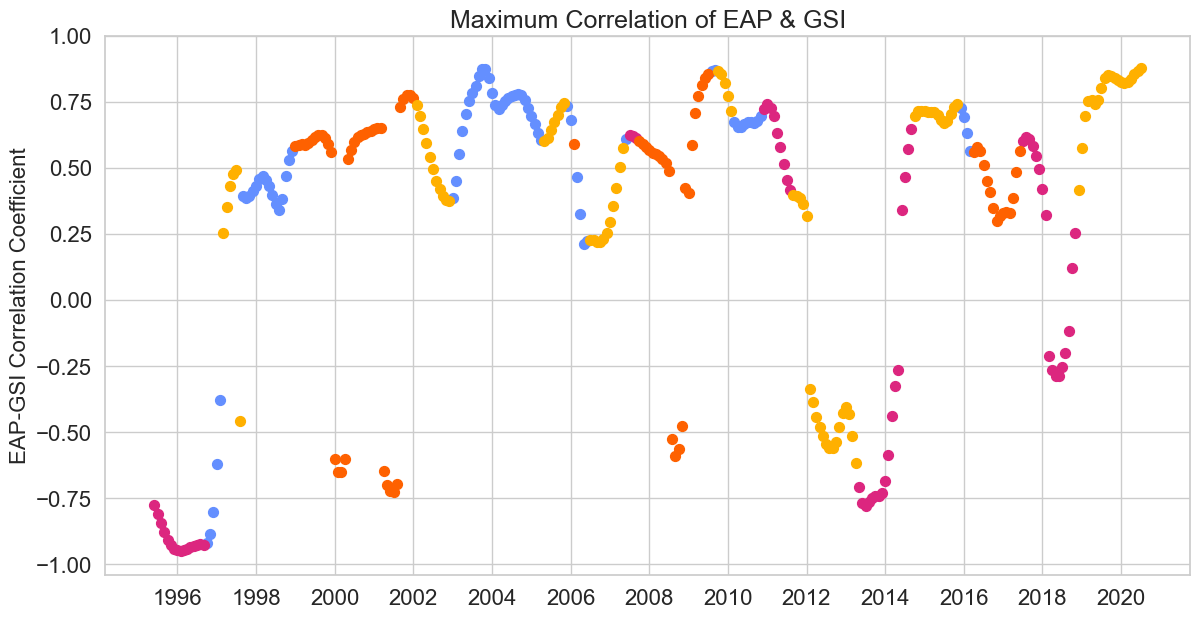

In [63]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['max_corr_eap'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['max_corr_eap'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['max_corr_eap'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['max_corr_eap'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['max_corr_eap'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Maximum Correlation of EAP & GSI',fontsize = 18)
plt.ylabel('EAP-GSI Correlation Coefficient', fontsize = 16)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-1,1.1,0.25),fontsize = 16)

In [64]:
df.to_csv(data_path + 'composite_logs_with_shape_clusters.csv')